<a href="https://colab.research.google.com/github/Visionary-DataWorks/DSPL-Project/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preparation

In [37]:
#Import Functions
import pandas as pd

In [38]:
#Load the preprocessed dataset
data=pd.read_csv('/content/cleaned_train_data.csv')

In [39]:
#print head
data.head()

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_category
0,10493832.0,Kelaniya,1209.60,756.00,5292.00,4
1,10178643.0,Moratuwa,1590.12,1060.08,6007.12,1
2,10513916.0,Wattala,2288.88,1481.04,9155.52,4
3,10334589.0,Wattala,2274.94,1739.66,9099.76,4
4,10458365.0,Kelaniya,2345.49,2069.55,9243.99,4


In [40]:
#Checking missing values
print(data.info())
print(data.isnull().sum)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774148 entries, 0 to 774147
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Customer_ID       774146 non-null  float64
 1   outlet_city       774148 non-null  object 
 2   luxury_sales      774148 non-null  float64
 3   fresh_sales       774148 non-null  float64
 4   dry_sales         774148 non-null  float64
 5   cluster_category  774148 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 35.4+ MB
None
<bound method DataFrame.sum of         Customer_ID  outlet_city  luxury_sales  fresh_sales  dry_sales  \
0             False        False         False        False      False   
1             False        False         False        False      False   
2             False        False         False        False      False   
3             False        False         False        False      False   
4             False        False     

In [41]:
print(data.columns)

Index(['Customer_ID', 'outlet_city', 'luxury_sales', 'fresh_sales',
       'dry_sales', 'cluster_category'],
      dtype='object')


In [42]:
#Define Features (X)and Target (Y)
x = data.drop(columns=['cluster_category','Customer_ID']) #independent variables
y = data['cluster_category'] #Target variable

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (774148, 4)
Target shape: (774148,)


In [43]:
from sklearn.preprocessing import LabelEncoder

# Label encoding for outlet city
le = LabelEncoder()
x['outlet_city'] = le.fit_transform(x['outlet_city'])

In [44]:
from sklearn.model_selection import train_test_split

#splitting data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state= 42, stratify= y)

print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)


Training set size: (619318, 4)
Testing set size: (154830, 4)


In [45]:
#check shape for whole dataset
print('Whole Data shape', data.shape)

Whole Data shape (774148, 6)


In [46]:
from sklearn. preprocessing import RobustScaler

#initialize scaler()
scaler = RobustScaler()

#fit &transform training data, transform testing data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## LogisticRegression

In [47]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(multi_class='ovr')
logreg.fit(x_train_scaled, y_train)
y_pred=logreg.predict(x_test_scaled)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [48]:
#To see the predicted values
print("Predicted Values: ", y_pred)

Predicted Values:  [5 4 4 ... 4 3 1]


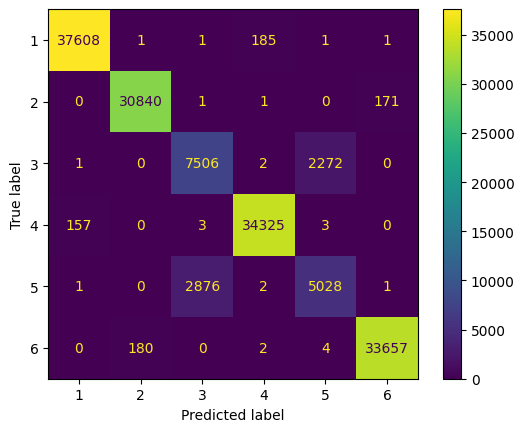

In [49]:
# plot of the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

confusion_m = confusion_matrix(y_test,y_pred,labels=logreg.classes_)

# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_m,display_labels=logreg.classes_)
disp.plot()

In [50]:
# Import the function calculate accuracy score
from sklearn.metrics import accuracy_score
# Apply the function to find the correct predictions
accuracy = accuracy_score(y_test,y_pred)
# Display the accuracy
print ('The Logistic Regression Model Accuracy:',accuracy)

The Logistic Regression Model Accuracy: 0.9621132855389782


In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.99      1.00     37797
           2       0.99      0.99      0.99     31013
           3       0.72      0.77      0.74      9781
           4       0.99      1.00      0.99     34488
           5       0.69      0.64      0.66      7908
           6       0.99      0.99      0.99     33843

    accuracy                           0.96    154830
   macro avg       0.90      0.90      0.90    154830
weighted avg       0.96      0.96      0.96    154830



ROC curve


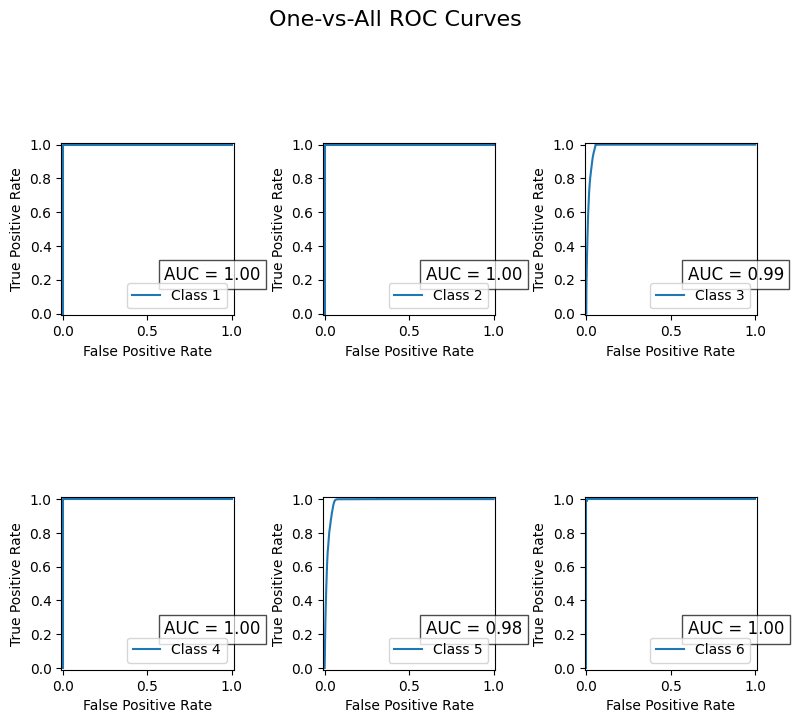

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_prob1 = logreg.predict_proba(x_test_scaled)

# Create  2x3 subplot layout
fig, axes = plt.subplots(2, 3, figsize=(8, 8))

# Flatten axes for easier indexing
axes = axes.flatten()

# Plot ROC curves for each class
for i, class_label in enumerate(logreg.classes_):
    fpr, tpr, _ = roc_curve(y_test == class_label, y_prob1[:, i])
    auc = roc_auc_score(y_test == class_label, y_prob1[:, i])
    RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'Class {class_label}').plot(ax=axes[i])
    axes[i].text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

plt.suptitle("One-vs-All ROC Curves", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

Learning curve

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

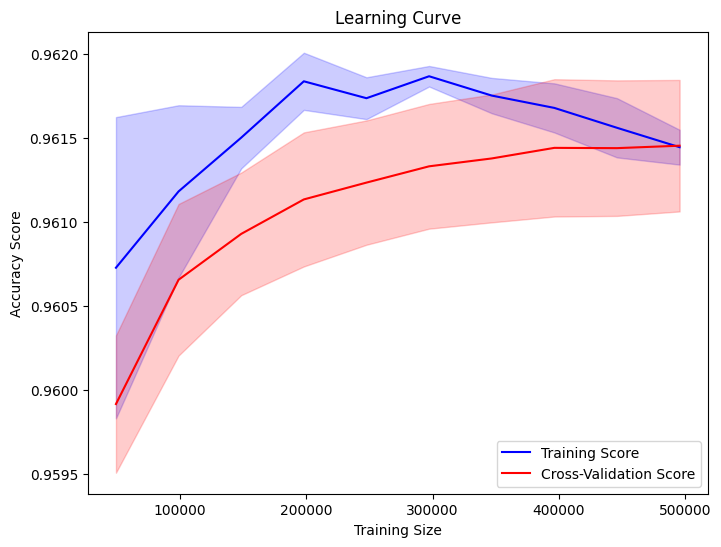

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

#define train sizes
train_sizes, train_scores, test_scores = learning_curve(logreg, x_train_scaled, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

#compare mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot Learning Curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='red')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.2)

plt.xlabel('Training Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.show()



##Hyperparameter Tunning

In [54]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform

param_dist = {
    'C': loguniform(1e-2, 1e2),     # Covers a wide but manageable range
    'penalty': ['l2'],             # L2 is reliable and efficient
    'solver': ['liblinear']        # Works well with small datasets and L2
}
log_reg = LogisticRegression(max_iter=300)

lr_rscv = RandomizedSearchCV(log_reg, param_distributions=param_dist,
                             n_iter=7, cv=3, scoring='roc_auc_ovr',
                             random_state=42, n_jobs=-1)  # n_jobs=-1 uses all CPU cores

# Replace 'X1_train' with 'x_train_scaled', which is the preprocessed training dataset.
lr_rscv.fit(x_train_scaled, y_train)

best_lr = lr_rscv.best_estimator_
print(best_lr)

LogisticRegression(C=np.float64(63.512210106407046), max_iter=300,
                   solver='liblinear')


In [55]:
# Check top performing n_neighbors’ value
lr_rscv.best_params_

{'C': np.float64(63.512210106407046), 'penalty': 'l2', 'solver': 'liblinear'}

In [56]:

# Perform testing on test dataset
y_pred_hy = lr_rscv.predict(x_test_scaled)

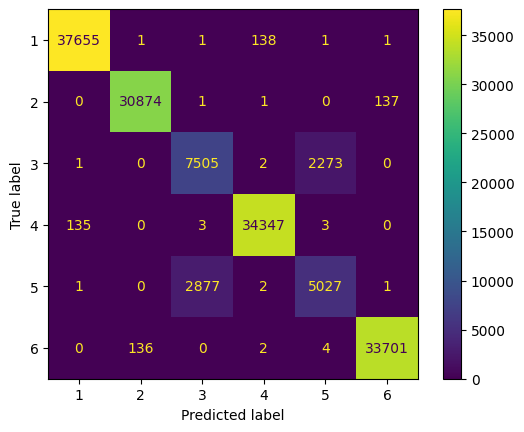

In [57]:
# Construct a confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm_loghy= confusion_matrix(y_test,y_pred_hy,labels=lr_rscv.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm_loghy,display_labels=lr_rscv.classes_)
disp.plot()



In [58]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_hy))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37797
           2       1.00      1.00      1.00     31013
           3       0.72      0.77      0.74      9781
           4       1.00      1.00      1.00     34488
           5       0.69      0.64      0.66      7908
           6       1.00      1.00      1.00     33843

    accuracy                           0.96    154830
   macro avg       0.90      0.90      0.90    154830
weighted avg       0.96      0.96      0.96    154830



In [59]:
#import the function calculate accuracy score
from sklearn.metrics import accuracy_score
#apply the function to find the correct predictions
accuracy = accuracy_score(y_test,y_pred_hy)
#display the accuracy
print ('The Logistic Regression Model Accuracy:',accuracy)


The Logistic Regression Model Accuracy: 0.963049796551056


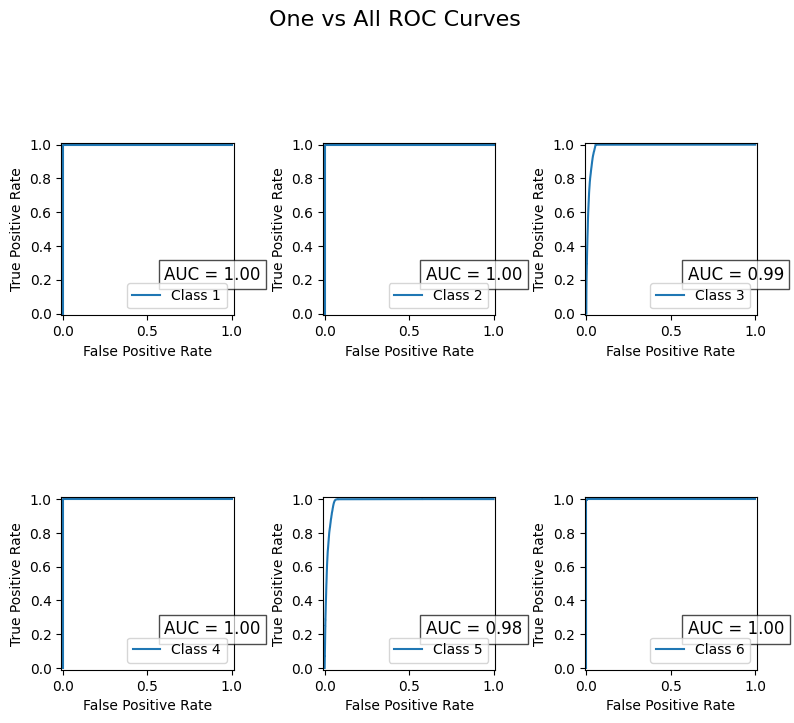

In [60]:
#ROC Curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get predicted probabilities for each class
y_prob1 = lr_rscv.predict_proba(x_test_scaled)

fig, axes = plt.subplots(2, 3, figsize=(8,8))

axes = axes.flatten()

# Plot ROC curves for each class
for i, class_label in enumerate(lr_rscv.classes_):
    fpr, tpr, _ = roc_curve(y_test == class_label, y_prob1[:, i])
    auc = roc_auc_score(y_test == class_label, y_prob1[:, i])
    RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name=f'Class {class_label}').plot(ax=axes[i])
    axes[i].text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

plt.suptitle("One vs All ROC Curves", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


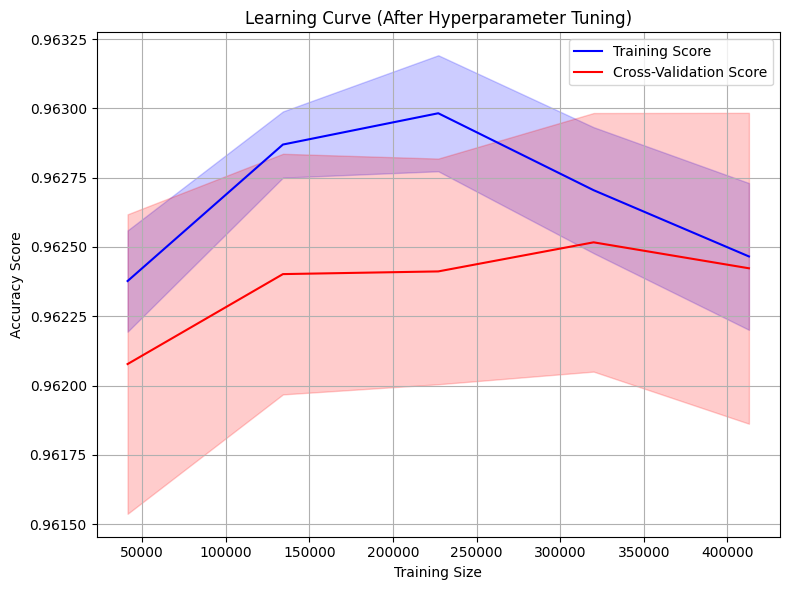

In [61]:
#Learing Curve
from sklearn.model_selection import learning_curve

# Use the best estimator (already fitted)
best_lr = lr_rscv.best_estimator_

# Learning curve with optimized settings
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_lr,
    X=x_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),  # Reduced to 5 points to speed up
    cv=3,                                  # Already used in RandomizedSearchCV
    scoring='accuracy',
    n_jobs=-1                              # Use all CPU cores
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot Learning Curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='red')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.2)

plt.xlabel('Training Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve (After Hyperparameter Tuning)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


In [62]:
import joblib
from google.colab import files

# Define models and preprocessing objects with filenames
objects_to_save = {"LabelEncoder": le, "scaler": scaler,"logreg":logreg}

# Save each object to a joblib file
for name, obj in objects_to_save.items():
    joblib.dump(obj, f"{name}.joblib")

# List of files to download
files_to_download = [f"{name}.joblib" for name in objects_to_save.keys()]

# Download each file
for file in files_to_download:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>